# Text Generation with a Transformer (Mini-GPT) — PyTorch

In this lab, you will train a **mini GPT-style Transformer** for text generation.
The objective is to understand how a **Transformer** can learn to predict the next token in a sequence and then generate text autoregressively.

# Learning Objectives

By the end of this lab, you should be able to:

- explain the general principle of autoregressive text generation
- understand how text is tokenized and converted to sequences (and build a simple tokenizer yourself)
- explain the role of token and position embeddings
- understand causal self-attention, and how to build a causal mask in PyTorch
- train a small GPT-style model
- generate text from a prompt, using both greedy and top-k sampling
- interpret the strengths and limitations of a miniature Transformer

# General Idea

A GPT-style language model learns to predict the **next token** in a sequence.

During training:
- the model sees a sequence of input tokens
- it learns to predict the following token at each position

During generation:
- we start with a prompt
- the model predicts the next token
- that token is appended to the prompt
- the process repeats autoregressively

# Step 1 — Import the Required Libraries

In [ ]:
import os
import re
import string
import tarfile
import urllib.request
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

np.random.seed(42)
torch.manual_seed(42)

PyTorch version: 2.11.0+cu128
Using device: cuda


# Step 2 — Download and Extract the Dataset

Even though IMDB is usually used for sentiment analysis, here we reuse the raw text for language modeling — the sentiment labels are ignored entirely.

We download and extract the same archive as the original notebook, using plain `urllib` + `tarfile` instead of `keras.utils.get_file`.

In [ ]:
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
archive_path = Path("aclImdb_v1.tar.gz")
dataset_dir = Path("aclImdb")

if not dataset_dir.exists():
    print("Downloading IMDB dataset...")
    urllib.request.urlretrieve(url, archive_path)
    print("Extracting...")
    with tarfile.open(archive_path) as tar:
        tar.extractall(".")
    archive_path.unlink()

train_dir = dataset_dir / "train"
print("Dataset directory:", dataset_dir)
print("Train directory exists:", train_dir.exists())

Extracting...


/tmp/ipykernel_716/2531238511.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(".")


Dataset directory: aclImdb
Train directory exists: True


# Step 3 — Read the Raw Text

We read every review in `train/pos` and `train/neg` as plain text (skipping `train/unsup`, which the original notebook also excluded). Only the text is needed for language modeling — no labels.

In [ ]:
texts = []
for subfolder in ["pos", "neg"]:
    folder = train_dir / subfolder
    for file_path in folder.glob("*.txt"):
        texts.append(file_path.read_text(encoding="utf-8"))

print("Number of reviews:", len(texts))
print("\nFirst review (first 500 characters):\n")
print(texts[0][:500])

Number of reviews: 25000

First review (first 500 characters):

Curl up with this one on a dark and stormy night and prepare to be alternately amused, irritated and frightened. The creaky old plot about about a phantom train that's said to run through the lonely English countryside at dead of night may be implausible, but it's a lot of fun. There are some wonderful old cliches like "THE ACCIDENT" which the locals can remember but won't talk about. But primarily the movie's a vehicle for comedian Arthur Askey to showcase his particular brand of vaudeville sty


# Step 4 — Build a Tokenizer and Vocabulary From Scratch

For `TextVectorization` we implement each step explicitly (subword tokenizers like BPE work the same way, just with a smarter splitting strategy than whitespace).

**Standardization** (same rules as the original): lowercase, replace HTML `<br />` tags with spaces, strip punctuation.

**Vocabulary:** we keep the `vocab_size - 2` most frequent words, reserving index `0` for padding (`<pad>`) and index `1` for out-of-vocabulary words (`<unk>`) — matching Keras's `TextVectorization` convention of `""` at index 0 and `"[UNK]"` at index 1.

In [ ]:
batch_size = 128
vocab_size = 20000
maxlen = 80


def standardize(text):
    text = text.lower()
    text = text.replace("<br />", " ")
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    return text


def tokenize(text):
    return standardize(text).split()


print("Building vocabulary (counting word frequencies across all reviews)...")
counter = Counter()
for text in texts:
    counter.update(tokenize(text))

most_common = counter.most_common(vocab_size - 2)
vocab = ["<pad>", "<unk>"] + [word for word, _ in most_common]
word_to_index = {word: idx for idx, word in enumerate(vocab)}

# Important: if the corpus has fewer unique words than the requested vocab_size,
# the actual vocabulary built above will be SMALLER than vocab_size. From here on,
# we use the true vocabulary length for every model dimension (embeddings, output layer).
# Otherwise the model could output logits for "phantom" token indices that were never
# seen during training (never trained, and not present in `vocab`), which can crash
# generation as soon as one of those indices gets sampled.
vocab_size = len(vocab)

print("Vocabulary size (actual):", vocab_size)
print("First 20 vocabulary items:", vocab[:20])

Building vocabulary (counting word frequencies across all reviews)...
Vocabulary size (actual): 20000
First 20 vocabulary items: ['<pad>', '<unk>', 'the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that', 'was', 'as', 'for', 'with', 'movie', 'but', 'film']


# Step 5 — Encode Text and Build Input/Target Pairs

For language modeling:
- the input sequence contains tokens from position `0` to `n-1`
- the target sequence contains tokens from position `1` to `n`

So the model learns to predict the **next token** at every position.

Each review is tokenized, converted to integer IDs, and padded/truncated to a fixed length of `maxlen + 1` (the `+1` is so that, after the input/target shift below, both `x` and `y` end up with length `maxlen`).

In [ ]:
def encode(text, max_len=maxlen + 1):
    tokens = tokenize(text)[:max_len]
    ids = [word_to_index.get(tok, 1) for tok in tokens]  # unknown words -> <unk> (index 1)
    ids = ids + [0] * (max_len - len(ids))  # pad with <pad> (index 0)
    return ids


print("Encoding all reviews (this may take a minute)...")
encoded = np.array([encode(text) for text in texts], dtype="int64")
print("Encoded shape:", encoded.shape)

x_all = encoded[:, :-1]
y_all = encoded[:, 1:]

print("\nExample input sequence: ", x_all[0][:20], "...")
print("Example target sequence:", y_all[0][:20], "...")

Encoding all reviews (this may take a minute)...
Encoded shape: (25000, 81)

Example input sequence:  [17602    56    16    11    28    20     4   459     3 12510   309     3
  5243     6    26  9349  5082  7784     3  5131] ...
Example target sequence: [   56    16    11    28    20     4   459     3 12510   309     3  5243
     6    26  9349  5082  7784     3  5131     2] ...


In [ ]:
train_dataset = TensorDataset(torch.tensor(x_all), torch.tensor(y_all))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print("Number of training batches:", len(train_loader))

Number of training batches: 196


# Step 6 — Token and Position Embeddings

The model needs:
- **token embeddings** to represent each word/token as a dense vector
- **position embeddings** to know the order of tokens in the sequence

Both are simple lookup tables (`nn.Embedding`), added together — identical in spirit to the original Keras layer.

In [ ]:
class TokenAndPositionEmbedding(nn.Module):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Embedding(maxlen, embed_dim)

    def forward(self, x):
        # x: (batch, seq_len) of token IDs
        seq_len = x.size(1)
        positions = torch.arange(seq_len, device=x.device)
        return self.token_emb(x) + self.pos_emb(positions)  # broadcasts over the batch dimension

# Step 7 — The Transformer Block (Causal Self-Attention)

The Transformer block contains:
- masked (causal) self-attention
- a feed-forward network
- residual connections
- layer normalization

**The causal mask** ensures that each position can only attend to itself and earlier positions — never future ones, which would let the model "cheat" by looking at the very token it's supposed to predict.

**PyTorch-specific note:** `nn.MultiheadAttention` takes an `attn_mask` argument: an additive mask where `-inf` at position `(i, j)` means "token `i` is not allowed to attend to token `j`". We build this once per forward pass as an upper-triangular matrix of `-inf` (everything *above* the diagonal — i.e. future positions), added to the raw attention scores before the softmax. This plays the same role as the boolean `causal_attention_mask` built manually in the original Keras version.

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = nn.MultiheadAttention(embed_dim, num_heads, dropout=rate, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim),
        )
        self.layernorm1 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.layernorm2 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.dropout1 = nn.Dropout(rate)
        self.dropout2 = nn.Dropout(rate)

    def forward(self, x):
        seq_len = x.size(1)
        # Additive causal mask: -inf strictly above the diagonal (future positions), 0 elsewhere
        causal_mask = torch.triu(torch.full((seq_len, seq_len), float("-inf"), device=x.device), diagonal=1)

        attention_output, _ = self.att(x, x, x, attn_mask=causal_mask, need_weights=False)
        attention_output = self.dropout1(attention_output)
        out1 = self.layernorm1(x + attention_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)
        return self.layernorm2(out1 + ffn_output)

# Step 8 — Build the Miniature GPT Model

We combine:
- token + position embeddings
- one Transformer block
- a final linear layer projecting onto the vocabulary (raw logits — `nn.CrossEntropyLoss` will apply `log_softmax` internally, just as in the earlier PyTorch labs)

In [ ]:
class MiniGPT(nn.Module):
    def __init__(self, maxlen, vocab_size, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.embedding = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)
        self.transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim, rate)
        self.output_proj = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer_block(x)
        return self.output_proj(x)  # (batch, seq_len, vocab_size)


embed_dim = 256
num_heads = 2
ff_dim = 256

model = MiniGPT(maxlen, vocab_size, embed_dim, num_heads, ff_dim).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 10,676,256


# Step 9 — Loss and Optimizer

We use `nn.CrossEntropyLoss`, the PyTorch equivalent of `SparseCategoricalCrossentropy(from_logits=True)`: it takes raw logits and integer targets directly. Since our logits have shape `(batch, seq_len, vocab_size)`, we flatten the batch and sequence dimensions together before computing the loss (`CrossEntropyLoss` expects `(N, C)` logits and `(N,)` targets).

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

# Step 10 — Text Generation Functions

We define the sampling logic **before** training, so we can peek at generated text every few epochs and watch the model improve — instead of only seeing the final result.

Two sampling strategies, to let us directly compare them later (see the Final Questions):
- **Top-k sampling** (used in the original notebook): restrict the choice to the `k` most likely next tokens, then sample from that shortlist according to their (renormalized) probabilities — introduces controlled randomness.
- **Greedy decoding**: always pick the single most likely next token (`argmax`) — fully deterministic, but prone to repetitive or dull text.

In [ ]:
index_to_word = {idx: word for word, idx in word_to_index.items()}


def sample_top_k(logits, k=10):
    top_logits, top_indices = torch.topk(logits, k)
    probs = torch.softmax(top_logits, dim=-1).cpu().numpy()
    top_indices = top_indices.cpu().numpy()
    return int(np.random.choice(top_indices, p=probs))


def sample_greedy(logits, k=None):
    return int(torch.argmax(logits).item())


def detokenize(token_ids):
    words = [index_to_word[tok] for tok in token_ids if tok not in (0,) and index_to_word.get(tok) != "<unk>"]
    return " ".join(words)


def generate_text(model, prompt, max_tokens=40, strategy="top_k", top_k=10):
    model.eval()
    generated = tokenize(prompt)
    generated_ids = [word_to_index.get(tok, 1) for tok in generated]

    sample_fn = sample_top_k if strategy == "top_k" else sample_greedy

    with torch.no_grad():
        while len(generated_ids) < max_tokens:
            window = generated_ids[-maxlen:]
            pad_len = maxlen - len(window)
            x = window + [0] * pad_len
            x_tensor = torch.tensor([x], dtype=torch.long, device=device)

            logits = model(x_tensor)  # (1, maxlen, vocab_size)
            sample_index = len(window) - 1
            next_token_logits = logits[0, sample_index]

            next_token = sample_fn(next_token_logits, k=top_k)
            generated_ids.append(next_token)

    return detokenize(generated_ids)

# Step 11 — Train the Model

Wo write an explicit training loop, like in the earlier labs. As a bonus, we print a sample of generated text every few epochs directly inline — a nice way to watch the model go from gibberish to (roughly) coherent phrases.

In [ ]:
prompt = "this movie is"
epochs = 15
generate_every = 3

history = {"loss": []}

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)  # (batch, seq_len, vocab_size)
        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        total += xb.size(0)

    epoch_loss = running_loss / total
    history["loss"].append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f}")

    if (epoch + 1) % generate_every == 0 or epoch == epochs - 1:
        sample = generate_text(model, prompt, max_tokens=30, strategy="top_k")
        print(f"  [sample] {sample}\n")

Epoch 1/15 - loss: 6.5311
Epoch 2/15 - loss: 5.7266
Epoch 3/15 - loss: 5.3758
  [sample] this movie is not to see it i have ever seen the plot is about this movie is a bad movie that i had to say that it would be

Epoch 4/15 - loss: 5.1531
Epoch 5/15 - loss: 4.9916
Epoch 6/15 - loss: 4.8657
  [sample] this movie is one of the most important movies but if it was a shame you can tell you this movie was a waste of time or not only it

Epoch 7/15 - loss: 4.7614
Epoch 8/15 - loss: 4.6750
Epoch 9/15 - loss: 4.5998
  [sample] this movie is one of the worst movies i have ever seen i have seen in this movie because i have seen a movie with some of the worst and

Epoch 10/15 - loss: 4.5358
Epoch 11/15 - loss: 4.4798
Epoch 12/15 - loss: 4.4294
  [sample] this movie is very good and the movie has been targeted for the story itself was made for a movie that is not only the first one of the best

Epoch 13/15 - loss: 4.3840
Epoch 14/15 - loss: 4.3430
Epoch 15/15 - loss: 4.3053
  [sample] this movie i

# Step 12 — Visualize the Training Loss

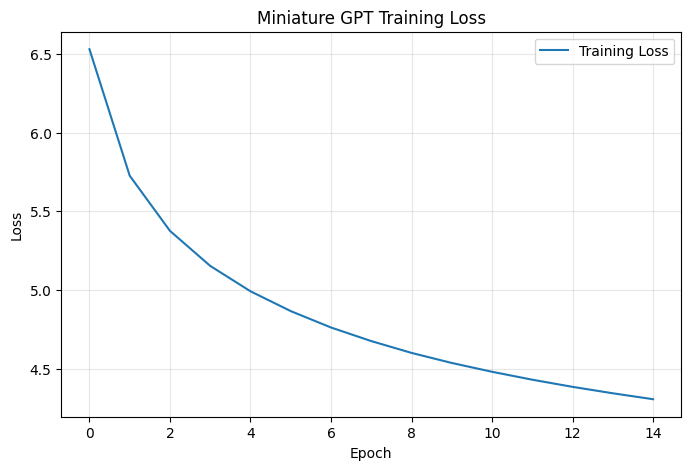

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history["loss"], label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Miniature GPT Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Step 13 — Generate Text From a Prompt

We compare **greedy** decoding against **top-k** sampling from the same prompt and the same trained model.

In [ ]:
prompt = "this movie is"

greedy_text = generate_text(model, prompt, max_tokens=40, strategy="greedy")
top_k_text = generate_text(model, prompt, max_tokens=40, strategy="top_k", top_k=10)

print("Greedy decoding:\n", greedy_text)
print("\nTop-k sampling (k=10):\n", top_k_text)

Greedy decoding:
 this movie is a great movie it is a great movie it is a great movie it is a great movie that is a great movie that is not a great movie but it is a great movie that is

Top-k sampling (k=10):
 this movie is a good example of horror film that has a good story but its not funny to be a character is very believable and it is very good the story follows the story of the film is


**Questions:**

1. Does the greedy output repeat itself more than the top-k output? Run the top-k generation a few times with the same prompt — does the output change each time? Does the greedy output ever change?
2. Try a different prompt and compare the two strategies again. Does the gap between them seem consistent?

# Suggested Improvements

You can extend this notebook by trying:

1. more training epochs
2. a larger vocabulary
3. a longer sequence length (`maxlen`)
4. more Transformer blocks (stack several `TransformerBlock` instances in `MiniGPT`)
5. a larger embedding dimension
6. different values of `top_k`
7. a different prompt for generation
8. **PyTorch-specific:** replace the hand-written `TransformerBlock` with `nn.TransformerEncoderLayer` (PyTorch's built-in equivalent) — note that you'll need to pass `is_causal=True` and a causal mask to its `forward` call to get the same masked self-attention behavior.

# Final Questions

Answer these global questions at the end of the lab:

1. What is the main difference between an LSTM and a Transformer for sequence modeling?
2. Why do we need a **causal mask** in a text generation model?
3. What is the role of token embeddings?
4. What is the role of position embeddings?
5. Why do we build shifted input/target sequences for language modeling?
6. Why is this dataset more suitable than a very small corpus for Transformer training?
7. Based on your comparison in Step 13, what are the practical limitations of greedy decoding with `argmax`? What does top-k sampling trade off in return?
8. How could you improve the generated text?
9. In `TransformerBlock`, the causal mask is built as an **additive** mask (`-inf` for disallowed positions) passed to `nn.MultiheadAttention`. Why does adding `-inf` before the softmax achieve the same effect as the boolean masking used in the original Keras version?
10. What practical differences did you notice between the Keras and PyTorch versions of this notebook (e.g. building the tokenizer/vocabulary from scratch, the explicit training loop, generating samples during training rather than via a callback)?

### Final Questions & Answers

#### 1. What is the main difference between an LSTM and a Transformer for sequence modeling?
* **Sequential vs. Parallel Processing:** LSTMs process tokens sequentially step-by-step, which creates a bottleneck because computation for a token cannot start until previous tokens are processed. Transformers process the entire sequence in parallel.
* **Attention vs. Recurrence:** LSTMs rely on internal hidden states to pass historical context forward, which struggles with long-range dependencies due to gradient vanishing/exploding. Transformers use self-attention, allowing any token to interact directly with any other token regardless of distance.

#### 2. Why do we need a causal mask in a text generation model?
* In autoregressive text generation, the model must predict the next token using only the history of already generated tokens.
* Without a causal mask, self-attention would look ahead at future tokens during training, allowing the model to "cheat" and easily minimize loss without learning how to generate text step-by-step.

#### 3. What is the role of token embeddings?
* Token embeddings map discrete categorical values (token indices/integers) into high-dimensional, continuous vectors.
* This represents each word in a dense semantic space where words with similar meanings or grammatical roles end up closer together.

#### 4. What is the role of position embeddings?
* Since self-attention is permutation-invariant (treating inputs as an unordered bag of words), the Transformer has no inherent sense of word order.
* Position embeddings inject sequential order information by adding position-specific coordinates/vectors to each token's embedding.

#### 5. Why do we build shifted input/target sequences for language modeling?
* We shift the target sequence by one position (`x = tokens[:-1]` and `y = tokens[1:]`) so that for every position $t$, the model's goal is to predict the token at $t+1$.
* This aligns perfectly with teacher forcing, where we feed the ground-truth sequence during training to predict the next token parallelly across all positions in a single forward pass.

#### 6. Why is this dataset more suitable than a very small corpus for Transformer training?
* Transformers have high capacity and contain millions of parameters (even this miniature one has over 10 million parameters).
* They lack strong inductive biases (unlike CNNs or RNNs) and require a substantial, diverse dataset (like the 25,000 IMDB reviews) to learn statistical patterns, grammar, and syntax without overfitting.

#### 7. Based on your comparison in Step 13, what are the practical limitations of greedy decoding with argmax? What does top-k sampling trade off in return?
* **Greedy Decoding:** Fully deterministic. It quickly gets stuck in highly repetitive, circular loops (e.g., repeating "it is a great movie it is a great movie").
* **Top-k Sampling:** Introduces controlled diversity. The trade-off is risk; occasionally, it may select a less probable, nonsensical token, trading off semantic accuracy and grammatical structure for variety.

#### 8. How could you improve the generated text?
* Stack multiple transformer encoder blocks to build deeper representation.
* Increase embedding dimensions and sequence lengths (`maxlen`).
* Implement more advanced decoding algorithms like Nucleus sampling (top-p), beam search, or use a temperature parameter to control randomness.
* Use a subword tokenizer (like Byte-Pair Encoding) rather than splitting strictly on white space.

#### 9. In TransformerBlock, the causal mask is built as an additive mask (-inf for disallowed positions) passed to nn.MultiheadAttention. Why does adding -inf before the softmax achieve the same effect as the boolean masking used in the original Keras version?
* The attention mechanism uses the softmax function: $\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum e^{z_j}}$.
* If we add $-\infty$ to a score, $e^{-\infty} \approx 0$. This forces the attention weight of blocked/future tokens to become exactly $0$ after softmax, mimicking a boolean mask which filters out those connections completely.

#### 10. What practical differences did you notice between the Keras and PyTorch versions of this notebook?
* **Preprocessing:** In Keras, `TextVectorization` is an out-of-the-box layer. In PyTorch, we build the dictionary mapping, standardization function, and padding logic explicitly.
* **Training loop:** PyTorch requires writing a manual training loop (handling optimizer, zeroing gradients, loss calculation, and weight updates manually), whereas Keras encapsulates this in `model.fit()`.
* **In-line generation:** We can directly call custom text-generation functions inside the manual epoch loop to inspect intermediate outputs, rather than relying on custom callback classes.